# High dimensional experiment.

Dataset: EdNet 
Models: MoLA, NeuralCDM

Predictive performance is evaluated using negative log-likelihood (NLL), Brier score, and area under the receiver operating characteristic curve (AUC). NLL and Brier score assess the quality of predicted response probabilities, while AUC measures discrimination between correct and incorrect responses.

We additionally report computational characteristics relevant to high-dimensional application, including the number of learners, items, skills, and observed responses, as well as model training time and memory requirements where available. These measurements characterize the practical scalability of the competing approaches in a large educational response dataset.

The resulting evaluation therefore addresses three distinct questions: (1) whether each model can estimate its population-level parameters from a large response dataset, (2) whether those parameters support estimation of proficiency for previously unseen learners from an initial response history, and (3) whether the resulting learner representation provides useful predictions of subsequent item responses. Question (3) is itself split into two distinct sub-questions -- see "Profiling and Prediction Splits" below.

## Methodological Details

The empirical evaluation uses a learner-level partition to prevent responses from the same learner from contributing to both population-level parameter estimation and final evaluation. We first retain learners with at least 30 observed item responses. The eligible learners are randomly divided into a parameter-estimation set and an evaluation set, with 70% of eligible learners assigned to parameter estimation and 30% to evaluation. The learner-level partition is identical across MoLA and NeuralCDM.

For MoLA, the number of archetypes \(M\) is treated as a model-selection hyperparameter and is selected using only the parameter-estimation learners. The parameter-estimation set is itself further split, with 80% of parameter-estimation learners (56% of all eligible learners) used to fit each candidate \(M\) and the remaining 20% (14% of all eligible learners) held out to score candidates by predictive log likelihood. Selecting \(M\) this way on a held-out slice and then training the chosen model on all the data that slice came from does not leak information into the final parameters: the held-out 14% only ever informs which \(M\) to use, never any model's fitted parameter values, until after that choice is fixed -- the same logic as k-fold cross-validation followed by a refit on the full training set. After selecting \(M\), MoLA is refit using all parameter-estimation learners (the full 70%). NeuralCDM has no analogous model-selection step -- its hyperparameters (epochs, embedding dimension, learning rate) are fixed by the researcher rather than tuned via held-out selection -- but is trained on the same full 70% of parameter-estimation learners. No responses from evaluation learners are used during selection of \(M\) or estimation of either model's final population-level parameters.


## Population-Level Parameter Estimation

For each model, all responses from learners in the parameter-estimation set are used to estimate the model's population-level parameters. For MoLA, these include the archetype proficiency parameters, item parameters, and mixture proportions. The resulting parameter estimates are denoted by $\hat{\Theta}_{\mathrm{MoLA}}$. NeuralCDM is trained using the same responses and the same item--skill associations available to MoLA.

No responses from learners in the evaluation set are used during this stage. After population-level estimation is complete, the resulting model parameters are fixed and are not subsequently updated using evaluation responses.

## Profiling and Prediction Splits

For each evaluation learner $n$, responses are divided into a profiling set (used to estimate the learner-specific latent representation) and a prediction set (withheld from that estimation, used only to evaluate subsequent response predictions). Let $T_n$ denote the learner's total number of eligible responses and

$$
T_n^{\mathrm{profile}}
=
\left\lfloor 0.60T_n \right\rfloor
$$

the number of profiling responses. Because learners are required to have at least 30 responses, each learner contributes a minimum of 18 responses to the profiling period and at least 12 responses to the prediction period.

*How* the two sets are chosen depends on which of two questions is being asked, so **every evaluation learner is scored under both**, independently:

- **Forecasting** (chronological mask): responses are sorted by their original timestamp; the first 60% form the profiling set and the final 40% form the prediction set. This asks whether the model can anticipate a learner's *future* performance on material encountered later, given their earlier trajectory -- profiling and prediction responses never overlap in time.
- **Tracking** (random mask): responses are randomly shuffled (independent of timestamp) before the same 60/40 split. This asks whether the model can reconstruct a learner's *current* proficiency from an arbitrary partial subset of their responses -- profiling and prediction responses are interleaved in time, so this does not test anticipation of the future, only reconstruction from incomplete information.

The two masks share every other aspect of the protocol (the same 60/40 ratio, the same frozen population parameters, the same profiling/prediction mechanics described below) -- the mask is the only thing that differs, so any gap between tracking and forecasting performance is attributable to the temporal-ordering question itself, not a confound from an unrelated methodological difference.

## MoLA Learner Profiling

Given the population-level parameter estimates $\hat{\Theta}_{\mathrm{MoLA}}$, we estimate each evaluation learner's latent archetype responsibilities using only their profiling responses (under whichever mask is being scored). Specifically, for learner $n$,

$$
\hat{\gamma}_{nm}
=
P(z_n=m
\mid
\mathbf{y}_{n,\mathrm{profile}},
\hat{\Theta}_{\mathrm{MoLA}}),
$$

where $z_n$ denotes the learner's latent archetype membership. The resulting responsibility vector $\hat{\boldsymbol{\gamma}}_n$ represents the learner's estimated position within the learned mixture of archetypes.

The population-level parameters remain fixed during this procedure. Thus, the profiling stage does not modify the learned archetypes, item parameters, or mixture proportions. Once $\hat{\boldsymbol{\gamma}}_n$ has been estimated, it is also held fixed throughout the prediction period.

For each item response $j$ in the prediction period, the predicted probability of a correct response is obtained by marginalizing over the learner's posterior archetype responsibilities,

$$
\hat{p}_{nj}
=
\sum_{m=1}^{M}
\hat{\gamma}_{nm}
P(Y_{nj}=1\mid z_n=m,\hat{\Theta}_{\mathrm{MoLA}}).
$$

Thus, prediction uses only the population-level parameters learned from the parameter-estimation learners and the evaluation learner's profiling history.

## NeuralCDM Learner Profiling

NeuralCDM is evaluated under the same information constraints. After training the population-level model using the parameter-estimation learners, its population-level parameters are held fixed. For each evaluation learner, the learner-specific proficiency representation is inferred using only the learner's profiling responses (under whichever mask is being scored). The inferred representation is then held fixed when predicting responses in the subsequent prediction period.

No prediction-period responses are used to update either the learner representation or the global model parameters.

## Prediction Evaluation

Predictions are evaluated against the observed responses in the prediction period. For each learner and each mask, model performance is computed over that mask's prediction-period responses. We report negative log-likelihood (NLL), Brier score, and area under the receiver operating characteristic curve (AUC), separately for the chronological (forecasting) and random (tracking) masks.

For binary responses $y_{nj}\in\{0,1\}$ and predicted probabilities $\hat{p}_{nj}$, the negative log-likelihood is

$$
\mathrm{NLL}
=
-\frac{1}{|\mathcal{D}_{\mathrm{pred}}|}
\sum_{(n,j)\in\mathcal{D}_{\mathrm{pred}}}
\left[
y_{nj}\log\hat{p}_{nj}
+
(1-y_{nj})\log(1-\hat{p}_{nj})
\right],
$$

where $\mathcal{D}_{\mathrm{pred}}$ denotes the set of all (learner, item) pairs in the prediction period for a given mask, pooled across evaluation learners. Brier score and AUC are computed analogously over the same pooled set of predictions.


## Running the Pipeline

The full protocol above is implemented in `src.experiments.high_dim`
(`split_learners`, `select_mola_m`, `fit_population_models`,
`evaluate_learner`, `run_evaluation`), backed by `src.utils.ednet` for
EdNet-KT1 data acquisition and `src.cdm.neural_cdm.NeuralCDM` for the
NCDM side. See `tests/test_ednet.py`, `tests/test_neural_cdm.py`, and
`tests/test_high_dim.py` for unit coverage of each piece on synthetic
data.

Before running against the full dataset (hundreds of thousands of
learners, a real training-time commitment for both models), we first run
`run_evaluation` on a small `max_users` subset -- a smoke test confirming
the pipeline runs end to end and produces sane (finite, in-range)
NLL/Brier/AUC for both models, not yet a reportable result.


In [1]:
import sys
sys.path.append("..")

In [2]:
from src.utils.ednet import sample_eligible_learners
from src.experiments.high_dim import run_evaluation

# Smoke scale: a small learner subset, not the full EdNet population.
N_LEARNERS = 200
MIN_RESPONSES = 30
MIN_ITEM_RESPONSES = 30

responses_df, Q, questions_df = sample_eligible_learners(
    n_learners=N_LEARNERS, min_responses=MIN_RESPONSES, min_item_responses=MIN_ITEM_RESPONSES, seed=0
)

print(f"learners: {responses_df['user_id'].nunique()}")
print(f"items: {Q.shape[0]}, skills: {Q.shape[1]}")
print(f"responses: {len(responses_df)}")


/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


learners: 200
items: 406, skills: 127
responses: 15102


In [3]:
M_GRID = [2, 4, 8, 16]

results = run_evaluation(
    responses_df,
    Q,
    questions_df,
    m_grid=M_GRID,
    seed=0,
    mola_kwargs={"max_iter": 50},
    neural_cdm_kwargs={"epoch": 10, "profile_epochs": 30, "batch_size": 256},
)
# one row per (evaluation learner, mask) -- "chronological" scores
# forecasting, "random" scores tracking (see the design doc above)

# select_mola_m's held-out NLL per candidate M (on the m_select learners) --
# the actual scores that determined selected_m below, not just its outcome.
m_select_nll = results.attrs["m_select_nll"]
print("held-out NLL by candidate M (lower is better):")
for m in M_GRID:
    marker = " <- selected" if m == results["selected_m"].iloc[0] else ""
    print(f"  M={m}: {m_select_nll[m]:.4f}{marker}")

print(f"\nselected M: {results['selected_m'].iloc[0]}")
print(f"MoLA population fit: {results['mola_train_time_sec'].iloc[0]:.1f}s, "
      f"NeuralCDM population fit: {results['neural_cdm_train_time_sec'].iloc[0]:.1f}s")
results.groupby("mask")[["mola_nll", "mola_brier", "mola_auc", "neural_cdm_nll", "neural_cdm_brier", "neural_cdm_auc"]].describe().T



Epoch 0:   0%|          | 0/37 [00:00<?, ?it/s]


Epoch 0:  43%|████▎     | 16/37 [00:00<00:00, 158.42it/s]


Epoch 0: 100%|██████████| 37/37 [00:00<00:00, 236.14it/s]

[Epoch 0] average loss: 8.257635



Epoch 1:   0%|          | 0/37 [00:00<?, ?it/s]

...


Epoch 9:   0%|          | 0/37 [00:00<?, ?it/s]


Epoch 9: 100%|██████████| 37/37 [00:00<00:00, 379.36it/s]

[Epoch 9] average loss: 0.689820


held-out NLL by candidate M (lower is better):
  M=2: 0.5987
  M=4: 0.5944
  M=8: 0.6012
  M=16: 0.5940 <- selected

selected M: 16
MoLA population fit: 0.1s, NeuralCDM population fit: 1.4s


mask                    chronological     random
mola_nll         count      60.000000  60.000000
                 mean        0.614617   0.615890
                 std         0.079889   0.080870
                 min         0.407947   0.408450
                 25%         0.561825   0.561683
                 50%         0.633509   0.627915
                 75%         0.669547   0.652461
                 max         0.774956   0.828252
mola_brier       count      60.000000  60.000000
                 mean        0.212778   0.213207
                 std         0.036625   0.036078
                 min         0.119549   0.120799
                 25%         0.189409   0.188091
                 50%         0.222261   0.218125
                 75%         0.236662   0.230684
                 max         0.285230   0.295561
mola_auc         count      60.000000  60.000000
                 mean        0.683520   0.692880
                 std         0.146986   0.176708
                 min         0.272727   0.000000
                 25%         0.603007   0.605547
                 50%         0.663876   0.684334
                 75%         0.766503   0.825969
                 max         1.000000   1.000000
neural_cdm_nll   count      60.000000  60.000000
                 mean        0.697496   0.695827
                 std         0.027146   0.022922
                 min         0.651589   0.655625
                 25%         0.679836   0.678718
                 50%         0.690419   0.689541
                 75%         0.706587   0.711953
                 max         0.758263   0.746768
neural_cdm_brier count      60.000000  60.000000
                 mean        0.252169   0.251336
                 std         0.013549   0.011440
                 min         0.229257   0.231272
                 25%         0.243355   0.242797
                 50%         0.248637   0.248199
                 75%         0.256706   0.259385
                 max         0.282498   0.276761
neural_cdm_auc   count      60.000000  60.000000
                 mean        0.596199   0.540996
                 std         0.168796   0.157978
                 min         0.281250   0.200000
                 25%         0.488616   0.435954
                 50%         0.559361   0.522762
                 75%         0.719464   0.640987
                 max         1.000000   0.962963

nll               brier                 auc  \
                              mean       std      mean       std      mean   
mask          model                                                          
chronological mola        0.614617  0.079889  0.212778  0.036625  0.683520   
              neural_cdm  0.697496  0.027146  0.252169  0.013549  0.596199   
random        mola        0.615890  0.080870  0.213207  0.036078  0.692880   
              neural_cdm  0.695827  0.022922  0.251336  0.011440  0.540996   

                                    
                               std  
mask          model                 
chronological mola        0.146986  
              neural_cdm  0.168796  
random        mola        0.176708  
              neural_cdm  0.157978

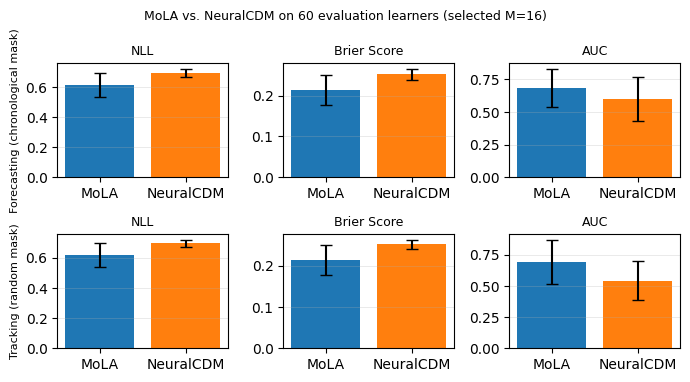

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

from src.style import figsize
from src.simulations.viz import _savefig

result_metrics = ["nll", "brier", "auc"]
result_labels = {"nll": "NLL", "brier": "Brier Score", "auc": "AUC"}
model_order = ["mola", "neural_cdm"]
model_labels = {"mola": "MoLA", "neural_cdm": "NeuralCDM"}
model_colors = {"mola": "#1f77b4", "neural_cdm": "#ff7f0e"}
mask_order = ["chronological", "random"]
mask_labels = {"chronological": "Forecasting (chronological mask)", "random": "Tracking (random mask)"}

comparison_long = pd.DataFrame(
    [
        {"user_id": row["user_id"], "mask": row["mask"], "model": model, **{m: row[f"{model}_{m}"] for m in result_metrics}}
        for _, row in results.iterrows()
        for model in model_order
    ]
)

# One row per mask (forecasting, tracking), one column per metric -- same
# small-multiples convention used throughout notebooks/simulation-study.ipynb.
fig, axes = plt.subplots(len(mask_order), 3, figsize=figsize("acm-sigconf-text", aspect=0.55), squeeze=False)
for row, mask in enumerate(mask_order):
    mask_data = comparison_long[comparison_long["mask"] == mask]
    for col, metric in enumerate(result_metrics):
        ax = axes[row, col]
        stats = mask_data.groupby("model")[metric].agg(["mean", "std"]).reindex(model_order)
        ax.bar(
            [model_labels[m] for m in stats.index], stats["mean"], yerr=stats["std"],
            capsize=4, color=[model_colors[m] for m in stats.index],
        )
        ax.set_title(result_labels[metric], fontsize=9)
        if col == 0:
            ax.set_ylabel(mask_labels[mask], fontsize=8)
        ax.grid(alpha=0.3, linewidth=0.6, axis="y")
fig.suptitle(
    f"MoLA vs. NeuralCDM on {results['user_id'].nunique()} evaluation learners (selected M={results['selected_m'].iloc[0]})",
    fontsize=9,
)
fig.tight_layout()
_savefig(fig, "figures/high_dim_comparison.pdf")

comparison_long.groupby(["mask", "model"])[result_metrics].agg(["mean", "std"]).reindex(mask_order, level="mask")


## Scaling: Performance vs. Population Size

The single-scale run above (`N_LEARNERS=200`) is a smoke test, not a
scale-controlled comparison. NeuralCDM has far more free parameters than
MoLA (item/knowledge embeddings feeding a 512-256-1 prediction network,
against MoLA's $M$-archetype-by-$K$-skill mixture) -- a classic
sample-complexity setup where the more constrained model can do better
with little data, while the more flexible one needs enough data to earn
out its extra capacity. This section characterizes that trade-off
directly: re-running the full pipeline (data loading, $M$-selection,
population fitting, evaluation under both masks) at increasing
population size, **reselecting $M$ at each scale** to mirror what you'd
actually do in practice rather than holding it fixed and confounding
"more data" with "a possibly-stale model-selection decision."

This is a genuinely separate experiment from the single-scale smoke test
above -- kept as its own section rather than modifying the existing
cells, which stay as a minimal, fast-to-run sanity check.

An earlier version of this section used a `MIN_ITEM_RESPONSES` tuned
separately per scale, believing the `AssertionError` it worked around was
a response-sparsity effect that got worse as `MAX_USERS` grew. It wasn't:
`load_ednet_q_matrix` was silently keeping items with no skill tag at all
(a missing `tags` field in the raw EdNet-Content data, ~6% of the
catalog) as an all-zero Q-matrix row. At inference time that zero row
makes MoLA's per-item normalization collapse to exactly 0, producing an
infinite log-likelihood term for any evaluation learner who happened to
answer that one item -- unrelated to `M` or to population size, and the
per-scale threshold only "fixed" it by coincidence (response-count
filtering happened to also filter out the untagged items at the
thresholds tried). `load_ednet_q_matrix` now drops untagged items
directly.

Two further changes since: first, `SCALE_POINTS` now names an exact
*eligible*-learner count rather than a raw sampling parameter --
`sample_eligible_learners` oversamples raw EdNet users and retries with
a larger raw pool as needed until enough survive the full eligibility
pipeline, then subsamples down to exactly that count, so the scale
points are the clean round numbers `[200, 500, 1000, 2000]` by
construction rather than whatever ragged count a fixed raw `MAX_USERS`
happened to yield. Second, `MIN_ITEM_RESPONSES` is now `30` everywhere
(matching `MIN_RESPONSES`) rather than a separately-tuned value -- it's
enforced on the larger oversampled pool each scale point is drawn from,
not re-verified on the exact final subsample (re-verifying it turned out
to be counterproductive: a larger raw pool pulls in more long-tail items
that sit just barely above the support threshold in aggregate, so
oversampling more aggressively to satisfy a strict post-trim check
actually left *less* per-item support after trimming, not more). This is
fine because `min_item_responses` is a soft data-quality knob, not a
correctness requirement -- MoLA handles low/zero-response items cleanly
via its prior regardless (see `sample_eligible_learners`'s docstring in
`src/utils/ednet.py` for the full account).


In [5]:
from src.utils.ednet import sample_eligible_learners
from src.experiments.high_dim import run_evaluation
import pandas as pd

SCALE_POINTS = [200, 500, 1000, 2000]
MIN_RESPONSES = 30
MIN_ITEM_RESPONSES = 30
SCALE_M_GRID = [2, 4, 8, 16]

scale_results = []
scale_stats = []
for n_learners in SCALE_POINTS:
    responses_df, Q, questions_df = sample_eligible_learners(
        n_learners=n_learners, min_responses=MIN_RESPONSES, min_item_responses=MIN_ITEM_RESPONSES, seed=0
    )

    results = run_evaluation(
        responses_df, Q, questions_df, m_grid=SCALE_M_GRID,
        seed=0, mola_kwargs={"max_iter": 50},
        neural_cdm_kwargs={"epoch": 10, "profile_epochs": 30, "batch_size": 256},
    )
    results["scale"] = n_learners
    scale_results.append(results)

    scale_stats.append({
        "Target Learners": n_learners,
        "Eligible Learners": responses_df["user_id"].nunique(),
        "Items": Q.shape[0],
        "Skills": Q.shape[1],
        "Responses": len(responses_df),
        "Selected M": results["selected_m"].iloc[0],
        "MoLA Fit (s)": results["mola_train_time_sec"].iloc[0],
        "NeuralCDM Fit (s)": results["neural_cdm_train_time_sec"].iloc[0],
    })
    print(f"n_learners={n_learners}: {scale_stats[-1]['Eligible Learners']} learners, "
          f"{scale_stats[-1]['Items']} items, selected M={scale_stats[-1]['Selected M']}")

scale_results = pd.concat(scale_results, ignore_index=True)



Epoch 0:   0%|          | 0/37 [00:00<?, ?it/s]


Epoch 0:  78%|███████▊  | 29/37 [00:00<00:00, 280.76it/s]


Epoch 0: 100%|██████████| 37/37 [00:00<00:00, 281.65it/s]

[Epoch 0] average loss: 8.257635



Epoch 1:   0%|          | 0/37 [00:00<?, ?it/s]

...


Epoch 9:  97%|█████████▋| 1554/1594 [00:06<00:00, 262.55it/s]


Epoch 9:  99%|█████████▉| 1581/1594 [00:06<00:00, 255.17it/s]


Epoch 9: 100%|██████████| 1594/1594 [00:06<00:00, 246.99it/s]

[Epoch 9] average loss: 0.449438


n_learners=2000: 2000 learners, 8715 items, selected M=16


### Dataset Statistics by Scale

In [6]:
scale_stats_df = pd.DataFrame(scale_stats).set_index("Target Learners").T
print(scale_stats_df.to_latex(
    float_format="%.1f",
    caption="Dataset statistics and selected $M$ at each population-size scale point.",
    label="tab:scale_dataset_stats",
))
scale_stats_df


\begin{table}
\caption{Dataset statistics and selected $M$ at each population-size scale point.}
\label{tab:scale_dataset_stats}
\begin{tabular}{lrrrr}
\toprule
Target Learners & 200 & 500 & 1000 & 2000 \\
\midrule
Eligible Learners & 200.0 & 500.0 & 1000.0 & 2000.0 \\
Items & 406.0 & 2023.0 & 4264.0 & 8715.0 \\
Skills & 127.0 & 168.0 & 182.0 & 187.0 \\
Responses & 15102.0 & 92384.0 & 220461.0 & 588906.0 \\
Selected M & 16.0 & 2.0 & 8.0 & 16.0 \\
MoLA Fit (s) & 0.1 & 0.5 & 1.5 & 2.2 \\
NeuralCDM Fit (s) & 1.0 & 8.1 & 21.0 & 61.2 \\
\bottomrule
\end{tabular}
\end{table}



Target Learners,200,500,1000,2000
Eligible Learners,200.000000,500.000000,1000.000000,2000.000000
Items,406.000000,2023.000000,4264.000000,8715.000000
Skills,127.000000,168.000000,182.000000,187.000000
Responses,15102.000000,92384.000000,220461.000000,588906.000000
Selected M,16.000000,2.000000,8.000000,16.000000
MoLA Fit (s),0.074578,0.505379,1.469592,2.163453
NeuralCDM Fit (s),1.047073,8.093730,20.973994,61.219233


### Performance vs. Scale, by Mask

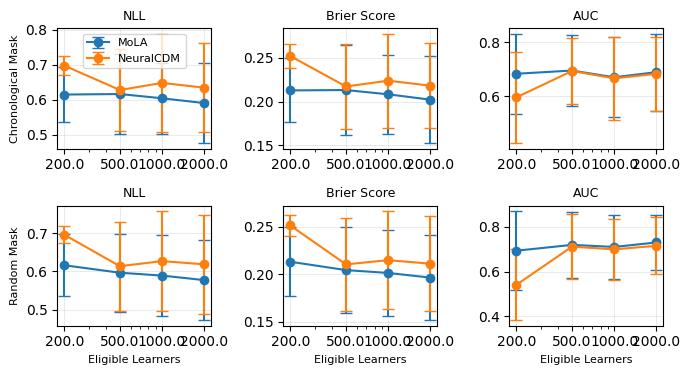

In [7]:
import matplotlib.pyplot as plt

from src.style import figsize
from src.simulations.viz import _savefig

result_metrics = ["nll", "brier", "auc"]
result_labels = {"nll": "NLL", "brier": "Brier Score", "auc": "AUC"}
model_order = ["mola", "neural_cdm"]
model_labels = {"mola": "MoLA", "neural_cdm": "NeuralCDM"}
model_colors = {"mola": "#1f77b4", "neural_cdm": "#ff7f0e"}
mask_order = ["chronological", "random"]
mask_labels = {"chronological": "Chronological Mask", "random": "Random Mask"}

scale_comparison_long = pd.DataFrame(
    [
        {"user_id": row["user_id"], "mask": row["mask"], "scale": row["scale"], "model": model,
         **{m: row[f"{model}_{m}"] for m in result_metrics}}
        for _, row in scale_results.iterrows()
        for model in model_order
    ]
)

# x-axis is Eligible Learners, not MAX_USERS: MAX_USERS is just the raw
# EdNet-user sampling parameter, not the data volume that actually drives
# model performance, and the eligibility rate isn't constant across scale
# points (confirmed: 200->45, 500->169, 1000->302 learners) -- plotting
# against MAX_USERS would misrepresent the sweep as evenly log-spaced when
# it isn't. scale_to_eligible maps each MAX_USERS scale point to its real
# eligible-learner count from the table above. scale_stats_df is indexed
# by stat name and columned by Target Learners (transposed for the paper
# table layout), so this reads a row via .loc, not a column.
scale_to_eligible = scale_stats_df.loc["Eligible Learners"].to_dict()

# Same small-multiples convention as the single-scale comparison above
# (2 masks x 3 metrics), but a line+errorbar plot against eligible-learner
# count on a log x-axis instead of a bar chart -- the whole point of this
# figure is to show how the gap between models closes as data grows.
fig, axes = plt.subplots(len(mask_order), 3, figsize=figsize("acm-sigconf-text", aspect=0.55), squeeze=False)
for row, mask in enumerate(mask_order):
    mask_data = scale_comparison_long[scale_comparison_long["mask"] == mask]
    for col, metric in enumerate(result_metrics):
        ax = axes[row, col]
        for model in model_order:
            stats = (
                mask_data[mask_data["model"] == model]
                .groupby("scale")[metric]
                .agg(["mean", "std"])
                .reindex(SCALE_POINTS)
            )
            x_values = [scale_to_eligible[s] for s in stats.index]
            ax.errorbar(
                x_values, stats["mean"], yerr=stats["std"],
                marker="o", capsize=4, color=model_colors[model], label=model_labels[model],
            )
        ax.set_xscale("log")
        eligible_ticks = [scale_to_eligible[s] for s in SCALE_POINTS]
        ax.set_xticks(eligible_ticks)
        ax.set_xticklabels([str(e) for e in eligible_ticks])
        ax.set_title(result_labels[metric], fontsize=9)
        if col == 0:
            ax.set_ylabel(mask_labels[mask], fontsize=8)
        if row == len(mask_order) - 1:
            ax.set_xlabel("Eligible Learners", fontsize=8)
        ax.grid(alpha=0.3, linewidth=0.6)
axes[0, 0].legend(fontsize=8)
# fig.suptitle("MoLA vs. NeuralCDM as a Function of Population Size", fontsize=9)
fig.tight_layout()
_savefig(fig, "../figures/high_dim_scaling.pdf")

### Is the Gap Between Models Statistically Significant?

The figure above shows means and one standard deviation per point, but
"the error bars overlap" is not a statistical claim -- it doesn't
account for sample size, and overlapping/non-overlapping error bars are
a well-known unreliable proxy for whether a difference is significant.
It's also the wrong comparison for this design: MoLA and NeuralCDM are
scored on the *same* evaluation learners' held-out responses at each
scale (`evaluate_learner` computes both models' metrics per learner), so
this is a **paired** comparison, not two independent samples -- an
unpaired test would throw away that pairing and dilute real differences
with learner-to-learner variance unrelated to which model is better.

`paired_bootstrap_diff` (`src/simulations/metrics.py`) resamples
evaluation learners with replacement, and for each resample recomputes
`mean(mola_metric) - mean(neural_cdm_metric)` on that same resampled
set -- preserving the pairing -- to build a 95% percentile CI for the
true difference. Two things this CI legitimately supports, and one it
does not:

- CI excludes zero -> the data support a real difference (in whichever
  direction the CI sits).
- CI includes zero -> **"no significant difference detected at this
  sample size."**
- CI includes zero does **not** support "the models are equivalent" --
  failing to reject a null of no difference isn't evidence the true
  difference is zero, only that this data can't distinguish it from
  zero. An actual equivalence claim needs a pre-specified practical-
  equivalence margin and a dedicated test (e.g. TOST), which this does
  not attempt.


In [8]:
from src.simulations.metrics import paired_bootstrap_diff

bootstrap_rows = []
for mask in mask_order:
    for scale in SCALE_POINTS:
        sd = scale_results[(scale_results["mask"] == mask) & (scale_results["scale"] == scale)]
        for metric in result_metrics:
            result = paired_bootstrap_diff(
                sd[f"mola_{metric}"].to_numpy(), sd[f"neural_cdm_{metric}"].to_numpy(), n_boot=10_000, seed=0
            )
            bootstrap_rows.append({
                "Mask": mask_labels[mask],
                "Eligible Learners": scale_to_eligible[scale],
                "Metric": result_labels[metric],
                "n": result["n"],
                "MoLA - NeuralCDM": result["point_diff"],
                "95% CI": f"[{result['ci_lo']:.4f}, {result['ci_hi']:.4f}]",
                "Significant": "yes" if result["excludes_zero"] else "no",
            })

bootstrap_df = pd.DataFrame(bootstrap_rows).set_index(["Mask", "Eligible Learners", "Metric"])
print(bootstrap_df.to_latex(
    float_format="%.4f",
    caption="Paired bootstrap (10{,}000 resamples) 95\\% CIs for MoLA $-$ NeuralCDM at each "
            "population size. ``Significant'' marks CIs that exclude zero.",
    label="tab:scale_paired_bootstrap",
))
bootstrap_df


\begin{table}
\caption{Paired bootstrap (10{,}000 resamples) 95\% CIs for MoLA $-$ NeuralCDM at each population size. ``Significant'' marks CIs that exclude zero.}
\label{tab:scale_paired_bootstrap}
\begin{tabular}{lllrrll}
\toprule
 &  &  & n & MoLA - NeuralCDM & 95% CI & Significant \\
Mask & Eligible Learners & Metric &  &  &  &  \\
\midrule
\multirow[t]{12}{*}{Chronological Mask} & \multirow[t]{3}{*}{200.000000} & NLL & 60 & -0.0829 & [-0.1071, -0.0609] & yes \\
 &  & Brier Score & 60 & -0.0394 & [-0.0507, -0.0292] & yes \\
 &  & AUC & 60 & 0.0873 & [0.0421, 0.1320] & yes \\
\cline{2-7}
 & \multirow[t]{3}{*}{500.000000} & NLL & 150 & -0.0115 & [-0.0246, 0.0018] & no \\
 &  & Brier Score & 150 & -0.0041 & [-0.0097, 0.0017] & no \\
 &  & AUC & 149 & 0.0016 & [-0.0111, 0.0144] & no \\
\cline{2-7}
 & \multirow[t]{3}{*}{1000.000000} & NLL & 300 & -0.0441 & [-0.0555, -0.0325] & yes \\
 &  & Brier Score & 300 & -0.0156 & [-0.0199, -0.0112] & yes \\
 &  & AUC & 296 & 0.0040 & [-0.0044, 0.0

n  MoLA - NeuralCDM  \
Mask               Eligible Learners Metric                               
Chronological Mask 200.0             NLL           60         -0.082879   
                                     Brier Score   60         -0.039391   
                                     AUC           60          0.087320   
                   500.0             NLL          150         -0.011528   
                                     Brier Score  150         -0.004077   
                                     AUC          149          0.001612   
                   1000.0            NLL          300         -0.044059   
                                     Brier Score  300         -0.015577   
                                     AUC          296          0.003980   
                   2000.0            NLL          600         -0.044061   
                                     Brier Score  600         -0.016051   
                                     AUC          593          0.006288   
Random Mask        200.0             NLL           60         -0.079938   
                                     Brier Score   60         -0.038130   
                                     AUC           60          0.151884   
                   500.0             NLL          150         -0.017078   
                                     Brier Score  150         -0.006019   
                                     AUC          150          0.007925   
                   1000.0            NLL          300         -0.037868   
                                     Brier Score  300         -0.013442   
                                     AUC          297          0.010612   
                   2000.0            NLL          600         -0.041349   
                                     Brier Score  600         -0.014645   
                                     AUC          599          0.014849   

                                                              95% CI  \
Mask               Eligible Learners Metric                            
Chronological Mask 200.0             NLL          [-0.1071, -0.0609]   
                                     Brier Score  [-0.0507, -0.0292]   
                                     AUC            [0.0421, 0.1320]   
                   500.0             NLL           [-0.0246, 0.0018]   
                                     Brier Score   [-0.0097, 0.0017]   
                                     AUC           [-0.0111, 0.0144]   
                   1000.0            NLL          [-0.0555, -0.0325]   
                                     Brier Score  [-0.0199, -0.0112]   
                                     AUC           [-0.0044, 0.0126]   
                   2000.0            NLL          [-0.0519, -0.0360]   
                                     Brier Score  [-0.0191, -0.0129]   
                                     AUC           [-0.0003, 0.0129]   
Random Mask        200.0             NLL          [-0.0999, -0.0598]   
                                     Brier Score  [-0.0471, -0.0290]   
                                     AUC            [0.1089, 0.1968]   
                   500.0             NLL          [-0.0277, -0.0070]   
                                     Brier Score  [-0.0102, -0.0020]   
                                     AUC           [-0.0016, 0.0175]   
                   1000.0            NLL          [-0.0472, -0.0285]   
                                     Brier Score  [-0.0169, -0.0099]   
                                     AUC            [0.0020, 0.0190]   
                   2000.0            NLL          [-0.0482, -0.0346]   
                                     Brier Score  [-0.0172, -0.0121]   
                                     AUC            [0.0086, 0.0211]   

                                                 Significant  
Mask               Eligible Learners Metric                   
Chronological Mask 200.0             NLL                 yes  
                                     Br

#### Convert to publication-ready format:

In [1]:
# Start from the original long-format bootstrap_df:
#
# Index: Mask, Eligible Learners, Metric
# Columns: n, MoLA - NeuralCDM, 95% CI, Significant

table_df = (
    bootstrap_df
    .reset_index()
    .pivot(
        index=["Mask", "Eligible Learners"],
        columns="Metric",
        values=["MoLA - NeuralCDM", "Significant"],
    )
)

# Flatten the resulting MultiIndex columns
table_df.columns = [
    f"{metric}_{value}".replace(" ", "_")
    for value, metric in table_df.columns
]

table_df = table_df.reset_index()

# Add significance markers
for metric in result_metrics:
    metric_label = result_labels[metric]
    value_col = f"MoLA_-_NeuralCDM_{metric_label}"
    sig_col = f"Significant_{metric_label}"

    table_df[metric_label] = table_df.apply(
        lambda row: (
            f"{row[value_col]:.4f}"
            + (r"$^{*}$" if row[sig_col] == "yes" else "")
        ),
        axis=1,
    )

# Keep only the columns needed for the paper
table_df = table_df[
    ["Mask", "Eligible Learners"] + [
        result_labels[metric] for metric in result_metrics
    ]
]

# Optional: make repeated mask labels blank
table_df["Mask"] = table_df["Mask"].where(
    table_df["Mask"].ne(table_df["Mask"].shift()), ""
)

print(
    table_df.to_latex(
        index=False,
        escape=False,
        caption=(
            "Paired differences in performance between MoLA and NeuralCDM "
            "across population sizes. Entries report MoLA $-$ NeuralCDM; "
            "negative values favor MoLA for NLL and Brier score, whereas "
            "positive values favor MoLA for AUC. Asterisks indicate that "
            "the 95\\% paired-bootstrap confidence interval excludes zero "
            "(10{,}000 resamples)."
        ),
        label="tab:scale_paired_bootstrap",
    )
)

NameError: name 'bootstrap_df' is not defined